# EgoTimeQA and Ego4D dataset exploration

This notebook documents my exploration of the EgoTimeQA and Ego4D dataset for IRIS.

# EgoTimeQA Data Preparation

## 1. Project Setup & Configuration
We establish the paths for our input data (the raw annotations) and our output targets. 
* **Annotations:** The QA pairs provided by the EgoTimeQA paper authors.
* **Metadata:** The `ego4d.json` obtained via the CLI (using the `--metadata` flag only).

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Project Paths
BASE_DIR = Path("/Users/marcushamelink/Developer/ml/IRIS-personal-tests/data")
DATA_DIR = BASE_DIR / "ego4d-data"

PATHS = {
    "annotations": BASE_DIR / "EgoTimeQA/unified/annotations.EgoTimeQA.json",
    # Obtained via `ego4d --metadata`
    "metadata": DATA_DIR / "ego4d.json",
    "output_uids": DATA_DIR / "target_clip_uids.txt",
    "output_meta": DATA_DIR / "target_clips_meta.json",
}

print(f"Root: {BASE_DIR}")

Root: /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data


## 2. Data Ingestion & Linking
We need to bridge the gap between the **Research Paper data** and the **Official Ego4D storage**.

The paper provides `video_id`s for their questions, but does not provide file paths or durations. By loading the official Ego4D metadata, we can cross-reference these IDs. 

**Note:** This step confirms that the `video_id` in the EgoTimeQA dataset corresponds to the `clip_uid` in the Ego4D ecosystem (pre-segmented clips), not the full-length raw videos. We create a **Pandas DataFrame** to unify this information for analysis.

In [33]:
# Load source datasets
with open(PATHS["annotations"]) as f:
    egotime_data = json.load(f)

with open(PATHS["metadata"]) as f:
    ego4d_meta = json.load(f)

# Extract unique target IDs from the paper's dataset
target_ids = {item["video_id"] for item in egotime_data if "video_id" in item}

# Build the master dataframe by linking targets to official metadata
matched_data = []
if "clips" in ego4d_meta:
    for clip in ego4d_meta["clips"]:
        # The "Handshake": Check if the official clip exists in our target list
        if clip["clip_uid"] in target_ids:
            matched_data.append({
                "clip_uid": clip["clip_uid"],
                "parent_uid": clip["video_uid"],
                "duration": clip["video_end_sec"] - clip["video_start_sec"],
                "s3_path": clip.get("s3_path", ""),
                "raw_meta": clip,  # Keep full object for downstream usage
            })

df = pd.DataFrame(matched_data)
print(f"Loaded {len(df)} clips (Coverage: {len(df) / len(target_ids):.1%})")
df.head(3)


Loaded 5389 clips (Coverage: 100.0%)


,clip_uid,parent_uid,duration,s3_path,raw_meta
0,00030ae8-e5c4-41ec-a8ea-63548a7665d6,da5bebf7-d7d0-4a1f-aab4-72027b74eb01,480.033333,s3://ego4d-cmu/public/v2/clips/00030ae8-e5c4-4...,{'clip_uid': '00030ae8-e5c4-41ec-a8ea-63548a76...
1,000eba33-8d14-446a-b016-19bd50e9a3b9,ab2bf67b-efc0-4448-8c91-a4cecb29691f,480.000000,,{'clip_uid': '000eba33-8d14-446a-b016-19bd50e9...
2,0014331f-18b1-4200-b4cd-bf55a08aa4fe,a67789f8-3788-4a8d-aba8-9b2c2945d457,300.000000,,{'clip_uid': '0014331f-18b1-4200-b4cd-bf55a08a...


## 3. Exploratory Analysis
Before downloading, we analyze the "cost" of the dataset. We look at the distribution of clip lengths to identify outliers or excessively long clips that might inefficiently consume storage and training time.

count    5389.000000
mean      416.384995
std       137.640422
min       179.933333
25%       300.000000
50%       479.966667
75%       480.000000
max      1200.066667
Name: duration, dtype: float64


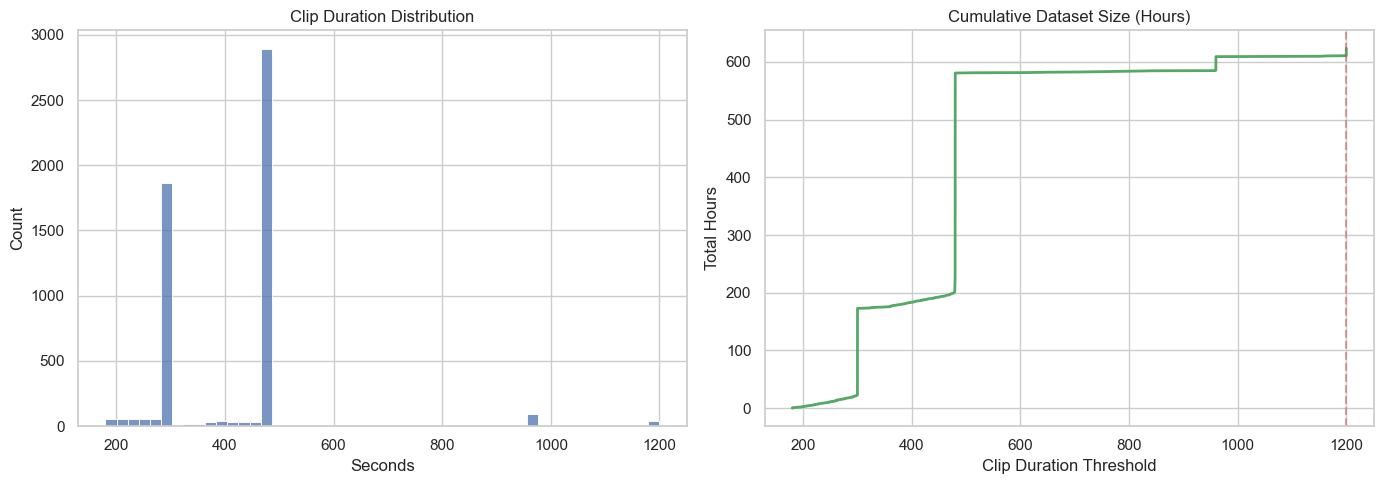

In [37]:
# Quick stats overview
print(df["duration"].describe())

# Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of lengths
sns.histplot(df["duration"], bins=50, color="#4c72b0", ax=ax[0]) # pyright: ignore[reportArgumentType]
ax[0].set_title("Clip Duration Distribution")
ax[0].set_xlabel("Seconds")

# Cumulative Volume (Pareto Chart)
sorted_dur = df.sort_values("duration")["duration"].cumsum() / 3600
ax[1].plot(df.sort_values("duration")["duration"], sorted_dur, color="#55a868", lw=2)
ax[1].set_title("Cumulative Dataset Size (Hours)")
ax[1].set_ylabel("Total Hours")
ax[1].set_xlabel("Clip Duration Threshold")

# Visualizing a 20-minute cut-off
ax[1].axvline(1200, color="r", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


## 4. Filtering & Export
Based on the analysis above, we create a download list. We filter out extremely long clips (if any) to ensure efficient data loading.

We export two files:
1.  `target_clip_uids.txt`: A clean list of IDs to feed into the `ego4d` CLI.
2.  `target_clips_meta.json`: A JSON file containing the start/end times and metadata for our specific subset, which will be used by our PyTorch/HF DataLoaders later.

In [38]:
# Filter Configuration
MAX_MINUTES = 20
max_seconds = MAX_MINUTES * 60

# Create subset
subset = df[df["duration"] <= max_seconds].copy()
dropped = len(df) - len(subset)

print(f"Filtering > {MAX_MINUTES} mins:")
print(f"- Retained: {len(subset)}")
print(f"- Dropped:  {dropped} ({dropped / len(df):.1%})")

# 1. Export UID list for Ego4D CLI
with open(PATHS["output_uids"], "w") as f:
    f.write("\n".join(subset["clip_uid"]))

# 2. Export Metadata for Dataloader
with open(PATHS["output_meta"], "w") as f:
    json.dump(subset["raw_meta"].tolist(), f, indent=2)

print(f"\nArtifacts saved to {DATA_DIR}")


Filtering > 20 mins:
- Retained: 5365
- Dropped:  24 (0.4%)

Artifacts saved to /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data/ego4d-data


I first want to download all the json metadata for ego4d.

We can get a `ego4d.json` file by running 
```bash
echo 'n' | uv run ego4d --output_directory ./ego4d-downloaded-data --metadata
```

This gives us a file with the metadata for each file in the dataset.

We can then generate from that a new ego4d.json which contains only the elements from the EgoTimeQA dataset.
This already restrains the contents.
This file allows us to explore the format of the dataset, along with the help of documentation.

This taught me that the `video_id` of the EgoTimeQA dataset directly corresponds to the `clip_uid` of Ego4D.

In [25]:
def inspect_dataset(file_path, name):
    """Quick peek at dataset structure"""
    print(f"--- Inspecting {name} ---")
    try:
        with open(file_path) as f:
            data = json.load(f)

        if isinstance(data, list):
            print(f"Root type: List with {len(data)} items")
            sample = data[0]
        elif isinstance(data, dict):
            print(f"Root keys: {list(data.keys())}")
            if "videos" in data:
                print(f"Found 'videos' key with {len(data['videos'])} items")
                sample = data["videos"][0]
            else:
                first_key = next(iter(data.keys()))
                sample = data[first_key]

        print(
            f"Sample Structure: {json.dumps(sample, indent=2, default=str)[:1000]}..."
        )
    except Exception as e:
        print(f"Error reading {name}: {e}")
    print("\n")


inspect_dataset(ANNOTATIONS["egotime"], "EgoTimeQA")


--- Inspecting EgoTimeQA ---
Root type: List with 302910 items
Sample Structure: {
  "video_id": "16fc2d81-e55c-4a3b-a298-b9d0272e9815",
  "sample_id": "16fc2d81-e55c-4a3b-a298-b9d0272e9815",
  "answer": "a paper",
  "question": "What did Person A pick up?",
  "moment_start_frame": 439.55793648760795,
  "moment_end_frame": 552.4420635123922,
  "wrong_answers": [
    "a pen",
    "a book",
    "a phone"
  ]
}...




## 2. Deep dive to understand the structure

We need a more systematic approach to explore the data.
Here we have an idea of the structure of both files, so we work with that.


In [27]:
"""Deep structure exploration tools"""


def get_nested_keys(
    data: dict, prefix: str = "", max_depth: int = 3, current_depth: int = 0
) -> list:
    """Recursively get all nested keys in a dictionary."""
    if current_depth >= max_depth:
        return []

    keys = []
    for key, value in data.items():
        current_key = f"{prefix}.{key}" if prefix else key
        keys.append(current_key)

        if isinstance(value, dict) and current_depth < max_depth - 1:
            keys.extend(
                get_nested_keys(value, current_key, max_depth, current_depth + 1)
            )
        elif isinstance(value, list) and len(value) > 0 and isinstance(value[0], dict):
            keys.append(f"{current_key}[0]")
            if current_depth < max_depth - 1:
                keys.extend(
                    get_nested_keys(
                        value[0], f"{current_key}[0]", max_depth, current_depth + 1
                    )
                )

    return keys


def get_first_elements(file_path: str, name: str = "Dataset") -> None:
    """Get the first element from each high-level key to understand data shape."""
    print(f"\n{'=' * 60}")
    print(f"First elements from: {name}")
    print(f"{'=' * 60}\n")

    try:
        with open(file_path, "r") as f:
            data = json.load(f)

        if isinstance(data, list):
            print(f"Root is a list with {len(data)} items")
            if len(data) > 0:
                data = data[0]

        for key in data.keys():
            value = data[key]
            print(f"\nKey: '{key}' | Type: {type(value).__name__}")

            if isinstance(value, list) and len(value) > 0:
                print(
                    f"First element:\n{json.dumps(value[0], indent=2, default=str)[:800]}"
                )
            elif isinstance(value, dict) and len(value) > 0:
                first_key = next(iter(value.keys()))
                print(
                    f"First dict entry (key: '{first_key}'):\n{json.dumps(value[first_key], indent=2, default=str)[:800]}"
                )

            print("-" * 60)

    except Exception as e:
        print(f"❌ Error: {e}")


# Explore both datasets
get_first_elements(ANNOTATIONS["egotime"], name="EgoTimeQA")
get_first_elements(ANNOTATIONS["ego4d"], name="Ego4D")


First elements from: EgoTimeQA

Root is a list with 302910 items

Key: 'video_id' | Type: str
------------------------------------------------------------

Key: 'sample_id' | Type: str
------------------------------------------------------------

Key: 'answer' | Type: str
------------------------------------------------------------

Key: 'question' | Type: str
------------------------------------------------------------

Key: 'moment_start_frame' | Type: float
------------------------------------------------------------

Key: 'moment_end_frame' | Type: float
------------------------------------------------------------

Key: 'wrong_answers' | Type: list
First element:
"a pen"
------------------------------------------------------------

First elements from: Ego4D


Key: 'date' | Type: str
------------------------------------------------------------

Key: 'version' | Type: str
------------------------------------------------------------

Key: 'description' | Type: str
------------------

In [13]:
import json
from pathlib import Path

# 1. Configuration
BASE_PATH = "/Users/marcushamelink/Developer/ml/IRIS-personal-tests/data"
ANNOTATIONS_PATH = Path(BASE_PATH) / "EgoTimeQA/unified/annotations.EgoTimeQA.json"
EGO4D_META_PATH = Path(BASE_PATH) / "ego4d-data/ego4d.json"

# Output paths
OUTPUT_UID_FILE = Path(BASE_PATH) / "ego4d-data/egotimeqa_uids.txt"
OUTPUT_SUBSET_JSON = Path(BASE_PATH) / "ego4d-data/egotimeqa-full.json"

# 2. Load Data
print(f"Loading annotations from: {ANNOTATIONS_PATH}")
with open(ANNOTATIONS_PATH, "r") as f:
    egotime_data = json.load(f)

print(f"Loading master metadata from: {EGO4D_META_PATH}")
with open(EGO4D_META_PATH, "r") as f:
    ego4d_data = json.load(f)

# 3. Extract Unique Video IDs (The Allowlist)
# Based on your schema description, the key is 'video_id'
target_uids = set()
for item in egotime_data:
    if "video_id" in item:
        target_uids.add(item["video_id"])

print(f"Found {len(target_uids)} unique video IDs in EgoTimeQA.")

# 4. Filter Ego4D Metadata
# We copy the main structure (date, version, etc.) but replace the 'videos' list
subset_meta = ego4d_data.copy()
filtered_videos = []

found_count = 0
for video in ego4d_data.get("videos", []):
    if video["video_uid"] in target_uids:
        filtered_videos.append(video)
        found_count += 1

subset_meta["videos"] = filtered_videos

# Sanity Check
print(f"Matched {found_count} videos in the master Ego4D manifest.")
if len(target_uids) > found_count:
    print(
        f"Warning: {len(target_uids) - found_count} IDs from EgoTimeQA were not found in ego4d.json."
    )

# 5. Export Outputs

# A: The UID text file for the CLI downloader
with open(OUTPUT_UID_FILE, "w") as f:
    for uid in sorted(list(target_uids)):
        f.write(f"{uid}\n")
print(f"Saved UID list for CLI to: {OUTPUT_UID_FILE}")

# B: The rich metadata subset JSON
with open(OUTPUT_SUBSET_JSON, "w") as f:
    json.dump(subset_meta, f, indent=2)
print(f"Saved subset metadata to: {OUTPUT_SUBSET_JSON}")


Loading annotations from: /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data/EgoTimeQA/unified/annotations.EgoTimeQA.json
Loading master metadata from: /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data/ego4d-data/ego4d.json
Found 5389 unique video IDs in EgoTimeQA.
Matched 0 videos in the master Ego4D manifest.
Saved UID list for CLI to: /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data/ego4d-data/egotimeqa_uids.txt
Saved subset metadata to: /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data/ego4d-data/egotimeqa-full.json


In [ ]:
import json
from pathlib import Path

# 1. Configuration
BASE_PATH = "/Users/marcushamelink/Developer/ml/IRIS-personal-tests/data"
ANNOTATIONS_PATH = Path(BASE_PATH) / "EgoTimeQA/unified/annotations.EgoTimeQA.json"
EGO4D_META_PATH = Path(BASE_PATH) / "ego4d-data/ego4d.json"
OUTPUT_UID_FILE = Path(BASE_PATH) / "ego4d-data/egotimeqa_uids.txt"
OUTPUT_SUBSET_JSON = Path(BASE_PATH) / "ego4d-data/egotimeqa-clips.json"

# 2. Load Data
print("Loading files...")
with open(ANNOTATIONS_PATH, "r") as f:
    egotime_data = json.load(f)
with open(EGO4D_META_PATH, "r") as f:
    ego4d_data = json.load(f)

# 3. Extract Target Clip IDs
# These are the IDs from the research paper's dataset
target_clip_ids = set()
for item in egotime_data:
    # The key 'video_id' in EgoTimeQA actually corresponds to 'clip_uid' in Ego4D
    if "video_id" in item:
        target_clip_ids.add(item["video_id"])

print(f"🎯 Target: Looking for {len(target_clip_ids)} unique Clip IDs.")

# 4. Map Clips to Parent Videos
# We iterate through the 'clips' list in ego4d.json to find matches
parent_video_uids = set()
found_clips_meta = []
found_count = 0

# ego4d.json has a top-level 'clips' key containing the mapping
if "clips" in ego4d_data:
    for clip in ego4d_data["clips"]:
        if clip["clip_uid"] in target_clip_ids:
            # Found a match!
            found_count += 1

            # 1. Add the PARENT video UID to the download list
            parent_video_uids.add(clip["video_uid"])

            # 2. Save the clip metadata (Crucial: contains start/end times for your embeddings)
            found_clips_meta.append(clip)

print(
    f"✅ Match Status: Found {found_count} / {len(target_clip_ids)} clips in manifest."
)
print(
    f"📹 Download List: These clips belong to {len(parent_video_uids)} unique parent videos."
)

# 5. Export Outputs

# A: The UID text file for the CLI (contains PARENT VIDEO UIDs)
# We use parent UIDs because the standard 'full_scale' download command expects them.
with open(OUTPUT_UID_FILE, "w") as f:
    for uid in sorted(list(parent_video_uids)):
        f.write(f"{uid}\n")
print(f"💾 Saved parent video UID list to: {OUTPUT_UID_FILE}")

# B: The detailed clip metadata
# Use this later to know exactly which seconds of the video to feed into Qwen2.5VL
with open(OUTPUT_SUBSET_JSON, "w") as f:
    json.dump(found_clips_meta, f, indent=2)
print(f"💾 Saved clip metadata to: {OUTPUT_SUBSET_JSON}")


Loading files...
🎯 Target: Looking for 5389 unique Clip IDs.
✅ Match Status: Found 5389 / 5389 clips in manifest.
📹 Download List: These clips belong to 1697 unique parent videos.
💾 Saved parent video UID list to: /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data/ego4d-data/egotimeqa_uids.txt
💾 Saved clip metadata to: /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data/ego4d-data/egotimeqa-clips.json


In [18]:
import json
from pathlib import Path

# Config
BASE_PATH = "/Users/marcushamelink/Developer/ml/IRIS-personal-tests/data"
ANNOTATIONS_PATH = Path(BASE_PATH) / "EgoTimeQA/unified/annotations.EgoTimeQA.json"
OUTPUT_CLIP_LIST = Path(BASE_PATH) / "ego4d-data/egotimeqa_clip_uids.txt"

# Load
with open(ANNOTATIONS_PATH, "r") as f:
    egotime_data = json.load(f)

# Extract strictly the IDs used in the dataset
clip_uids = set()
for item in egotime_data:
    if "video_id" in item:
        clip_uids.add(
            item["video_id"]
        )  # Remember: In this dataset, 'video_id' is actually the Clip UID

# Save for CLI
with open(OUTPUT_CLIP_LIST, "w") as f:
    for uid in sorted(list(clip_uids)):
        f.write(f"{uid}\n")

print(f"✅ Saved {len(clip_uids)} Clip UIDs to {OUTPUT_CLIP_LIST}")


✅ Saved 5389 Clip UIDs to /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data/ego4d-data/egotimeqa_clip_uids.txt


In [24]:
# Quick filter for small clips only - with duration distribution analysis
import json
from collections import Counter

BASE_PATH = "/Users/marcushamelink/Developer/ml/IRIS-personal-tests/data"
input_path = Path(BASE_PATH) / "ego4d-data/egotimeqa-clips.json"
output_txt = Path(BASE_PATH) / "ego4d-data/small_clips_uids.txt"

with open(input_path) as f:
    clips = json.load(f)

# Calculate durations and sort
durations = []
for c in clips:
    duration = c["video_end_sec"] - c["video_start_sec"]
    durations.append(duration)

# Sort durations from longest to shortest
sorted_durations = sorted(durations, reverse=True)

# Show some statistics
print(f"Total clips: {len(clips)}")
print(
    f"Longest clip: {sorted_durations[0]:.1f} seconds ({sorted_durations[0] / 60:.1f} minutes)"
)
print(f"Shortest clip: {sorted_durations[-1]:.1f} seconds")
print(f"Average duration: {sum(durations) / len(durations):.1f} seconds")
print()

# Create duration ranges and count clips in each
ranges = [
    (0, 30, "0-30 sec"),
    (30, 60, "30-60 sec (1 min)"),
    (60, 120, "1-2 min"),
    (120, 300, "2-5 min"),
    (300, 600, "5-10 min"),
    (600, 1200, "10-20 min"),
    (1200, 1800, "20-30 min"),
    (1800, 3600, "30-60 min"),
    (3600, float("inf"), "60+ min"),
]

print("Duration Distribution:")
print("-" * 50)
cumulative = 0
for min_dur, max_dur, label in ranges:
    count = sum(1 for d in durations if min_dur <= d < max_dur)
    cumulative += count
    percentage = (count / len(clips)) * 100
    cumulative_pct = (cumulative / len(clips)) * 100
    print(
        f"{label:20} {count:5} clips ({percentage:5.1f}%) | Cumulative: {cumulative:5} ({cumulative_pct:5.1f}%)"
    )

# Optional: Filter with your chosen MAX_DURATION
MAX_DURATION = 60 * 20  # 20 minutes
short_clips = [
    c["clip_uid"]
    for c in clips
    if (c["video_end_sec"] - c["video_start_sec"]) < MAX_DURATION
]

print()
print(
    f"With MAX_DURATION = {MAX_DURATION / 60:.0f} min: {len(short_clips)} clips ({len(short_clips) / len(clips) * 100:.1f}%)"
)


Total clips: 5389
Longest clip: 1200.1 seconds (20.0 minutes)
Shortest clip: 179.9 seconds
Average duration: 416.4 seconds

Duration Distribution:
--------------------------------------------------
0-30 sec                 0 clips (  0.0%) | Cumulative:     0 (  0.0%)
30-60 sec (1 min)        0 clips (  0.0%) | Cumulative:     0 (  0.0%)
1-2 min                  0 clips (  0.0%) | Cumulative:     0 (  0.0%)
2-5 min                898 clips ( 16.7%) | Cumulative:   898 ( 16.7%)
5-10 min              4340 clips ( 80.5%) | Cumulative:  5238 ( 97.2%)
10-20 min              113 clips (  2.1%) | Cumulative:  5351 ( 99.3%)
20-30 min               38 clips (  0.7%) | Cumulative:  5389 (100.0%)
30-60 min                0 clips (  0.0%) | Cumulative:  5389 (100.0%)
60+ min                  0 clips (  0.0%) | Cumulative:  5389 (100.0%)

With MAX_DURATION = 20 min: 5351 clips (99.3%)
